**任务：**  
**1. 更正如下基于Pytorch框架构建的手写体数字识别CNN网络**

**思路：**  
**1. 对应处进行补全或删改即可**

## 读取数据

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import gzip
import os
import struct
import numpy as np
import matplotlib.pyplot as plt

def load_mnist(path, kind='train'):
    """加载MNIST数据集"""
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')

    with gzip.open(labels_path, 'rb') as lbpath:
        struct.unpack('>II', lbpath.read(8))
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8)

    with gzip.open(images_path, 'rb') as imgpath:
        struct.unpack('>IIII', imgpath.read(16))
        images = np.frombuffer(imgpath.read(), dtype=np.uint8).reshape(len(labels),1,28,28)

    return images, labels



# 数据集划分
def data_split(images, labels, ratio):
    
    total_len = images.shape[0]
    offset = int(total_len * ratio)

    val_img = images[:offset][:]
    val_lb = labels[:offset]

    train_img = images[offset:][:]
    train_lb = labels[offset:]

    return train_img, train_lb, val_img, val_lb    

# 读取训练集和测试集数据
[images, labels] = load_mnist('./MNIST', kind='train')  #同级目录下文件的配置结构按照个人喜好来即可
[test_img, test_lb] = load_mnist('./MNIST',kind='test')
train_img, train_lb, val_img, val_lb = data_split(images, labels, 1/6)

# 为了加快调试速度，从训练集选择2000个样本。
random_numbers = np.random.randint(50000, size=(2000, ))
train_img=train_img[random_numbers]
train_lb= train_lb [random_numbers]

# 将所有数据归一化到0-1之间
train_img =train_img/255.
val_img   =val_img/255.
test_img  =test_img/255.

# 对标签进行热编码
one_hot_train_lb = np.eye(10)[train_lb]
one_hot_val_lb = np.eye(10)[val_lb]
one_hot_test_lb= np.eye(10)[test_lb]

# 打印查看数据集格式
print('训练集图像格式为:', train_img.shape, '训练集标签格式为:', train_lb.shape,'热编码训练集标签格式为:', one_hot_train_lb.shape)
print('验证集图像格式为:', val_img.shape, '验证集标签格式为:', val_lb.shape,'热编码验证集标签格式为:', one_hot_val_lb.shape)
print('测试集图像格式为:', test_img.shape, '测试集标签格式为:', test_lb.shape,'热编码测试集标签格式为:', one_hot_test_lb.shape)

训练集图像格式为: (2000, 1, 28, 28) 训练集标签格式为: (2000,) 热编码训练集标签格式为: (2000, 10)
验证集图像格式为: (10000, 1, 28, 28) 验证集标签格式为: (10000,) 热编码验证集标签格式为: (10000, 10)
测试集图像格式为: (10000, 1, 28, 28) 测试集标签格式为: (10000,) 热编码测试集标签格式为: (10000, 10)


## 数据增强处理

In [2]:
from torchvision.transforms import v2
from torchvision.io import read_image
train_img1=torch.tensor(train_img, dtype=torch.float32)  #此处将train_img1的数据类型由numpy.ndarray改为torch.tensor
                                                         #Ptorch框架中的相关运算均只支持tensor型数据，不支持ndarray
val_img=torch.tensor(val_img,dtype=torch.float32)  #验证集同理

transforms = v2.Compose([  #此处定义了一个数据增强流水线
    v2.RandomHorizontalFlip(p=0.5),  #对样本进行随机水平翻转，概率为50%
    v2.Normalize(mean=[0.485], std=[0.229]),  #对样本进行归一化，我们可以指定其均值和标准差
    v2.RandomRotation(degrees=(0, 180))  #对样本进行随机旋转
    ])
augmented_sample = transforms(train_img1)  #获取原始训练集的增强版本
train_img = torch.cat((augmented_sample,train_img1))  #把增强样本和原始样本拼接在一起作为最终的训练集
                                                      #相当于将样本翻倍了
one_hot_train_lb  = np.concatenate((one_hot_train_lb,one_hot_train_lb),axis=0)  #记得也要将标签复制一遍，保证样本数一致
one_hot_train_lb = torch.tensor(one_hot_train_lb, dtype=torch.float32)  #最好也将独热编码标签的数据类型也改为torch.tensor
one_hot_val_lb=torch.tensor(one_hot_val_lb,dtype=torch.float32)  #验证集同理

## 程序改错，构建并训练一个卷积网络

Epoch:1, train_loss: 2.084990, train_accuracy: 38.4%, val_loss: 1.939374, val_accuracy: 64.6%
Epoch:2, train_loss: 1.559129, train_accuracy: 69.0%, val_loss: 1.518073, val_accuracy: 75.2%
Epoch:3, train_loss: 1.169648, train_accuracy: 76.7%, val_loss: 1.245210, val_accuracy: 79.5%
Epoch:4, train_loss: 0.932820, train_accuracy: 80.1%, val_loss: 1.069135, val_accuracy: 81.7%
Epoch:5, train_loss: 0.786464, train_accuracy: 81.9%, val_loss: 0.950096, val_accuracy: 83.2%
Epoch:6, train_loss: 0.688332, train_accuracy: 83.5%, val_loss: 0.864046, val_accuracy: 84.4%
Epoch:7, train_loss: 0.616999, train_accuracy: 85.0%, val_loss: 0.798141, val_accuracy: 85.4%
Epoch:8, train_loss: 0.562024, train_accuracy: 86.1%, val_loss: 0.745918, val_accuracy: 86.1%
Epoch:9, train_loss: 0.517753, train_accuracy: 87.1%, val_loss: 0.703182, val_accuracy: 86.8%
Epoch:10, train_loss: 0.480906, train_accuracy: 87.9%, val_loss: 0.667501, val_accuracy: 87.2%
Epoch:11, train_loss: 0.449505, train_accuracy: 88.6%, val_

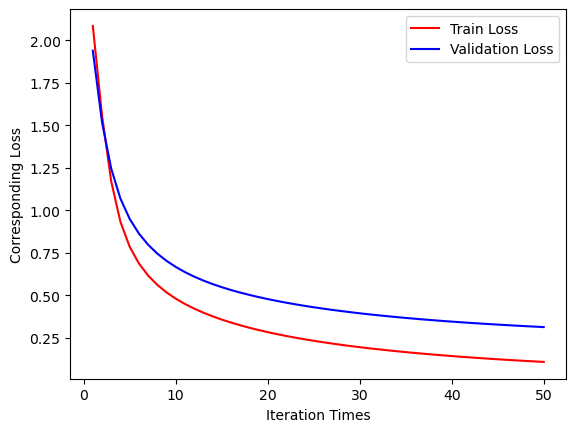

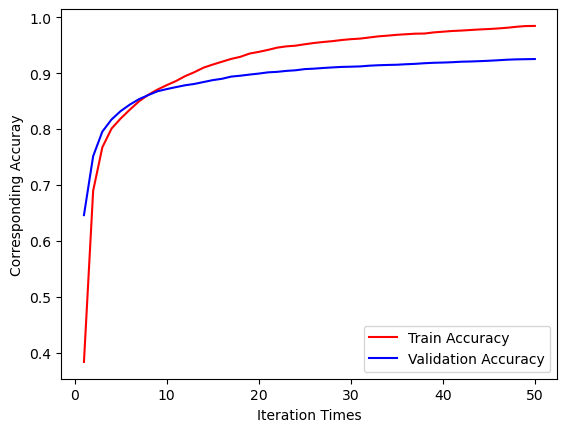

In [3]:
#网络包含3个卷积层、2个线性层、3个BN层
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()  #__init__()方法直接继承父类nn.Module
        """以下为卷积层"""
        self.conv1=nn.Conv2d(in_channels=1, kernel_size=3,out_channels=10,padding=1)  #!修改，我们不妨保持长宽均为28不变
        self.conv2=nn.Conv2d(in_channels=10,kernel_size=3,out_channels=20,padding=1)
        self.conv3=nn.Conv2d(in_channels=20,kernel_size=3,out_channels=30,padding=1)
        """以下为全连接层"""
        self.w1 =nn.Linear(30*28*28,100)
        self.w2 =nn.Linear(100,10)
        """以下为BN层"""
        self.BN1=nn.BatchNorm2d(10)  #!修改，BN层需要传入通道数，否则报错
        self.BN2=nn.BatchNorm2d(20)
        self.BN3=nn.BatchNorm2d(30)
        """以下为激活函数"""
        self.relu=nn.ReLU()


    def forward(self, x):
        x = self.conv1 (x)
        x = self.BN1(x)  #BN层要放到卷积层和激活函数之间，以后不再赘述
        x = self.relu(x)

        x = self.conv2 (x)
        x = self.BN2(x)  #!修改，此处应为BN2而不是BN1
        x = self.relu(x)

        x = self.conv3 (x)
        x = self.BN3(x)  #!修改，此处应为BN3而不是BN1
        x = self.relu(x)

        x = x.view(x.size(0), -1)  #扁平化flatten操作，将每个样本变为一个向量
        x = self.w1 (x)
        x = self.relu(x)

        x = self.w2 (x)  #!修改，输出层应使用softmax而不是relu作为激活函数      
                         #事实上，Pytorch内置的cross-entropy内置了softmax，所以我们这里可以不用写了
        return x

model = NeuralNetwork()  #实例化model

# Initialize the loss function
loss_fn = nn.CrossEntropyLoss()

learning_rate = 0.001
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

batch_size = 64
epochs = 50
batch_num=int(train_img.shape[0]/batch_size)
size = len(train_img)

model.train()

train_losses=[]
train_accuracies=[]
val_losses=[]
val_accuracies=[]

for t in range(epochs):
    
    train_correct=0.
    train_mean_loss=0.
    val_correct=0.
    val_mean_loss=0.

    model.train()  #此时对应训练集
    for batch in range(batch_num):
        X=train_img[batch*batch_size:(batch+1)*batch_size]
        y=one_hot_train_lb[batch*batch_size:(batch+1)*batch_size]

        #!修改，此处X和y已经是张量了，不建议再套一层torch.tensor,所以我将这两条语句删除了
        #实际上，我们在数据增强的地方已经将其强转为torch.tensor了
     
        # Compute prediction and loss
        pred_train = model(X)
        loss_train = loss_fn(pred_train, y)

        # Backpropagation
        #!修改，此处语句顺序有误，每个batch
        optimizer.zero_grad()  #清空梯度，值得一提的是Pytorch中梯度的计算是累积的，如果不在每一轮epoch中将梯度清零，
                               #那么会对后继更新造成很大的影响
        loss_train.backward()  #反向传播
        optimizer.step()  #梯度更新

        train_correct += (pred_train.argmax(1) == y.argmax(1)).type(torch.float).mean().item()
        train_mean_loss+= loss_train.item()

    train_mean_loss /= batch_num
    train_correct /= batch_num

    train_losses.append(train_mean_loss)
    train_accuracies.append(train_correct)

    model.eval()  #此时对应验证集
    with torch.no_grad():
        pred_val = model(val_img)
        loss_val = loss_fn(pred_val, one_hot_val_lb)
        val_correct = (pred_val.argmax(1) == one_hot_val_lb.argmax(1)).float().mean().item()
        
    val_losses.append(loss_val)
    val_accuracies.append(val_correct)

    #!修改，此处修改无关紧要，因为t在[0,9]中，改成t+1则可输出[1,10]，更符合正常逻辑
    print(f"Epoch:{t+1}, train_loss: {train_mean_loss:>8f}, train_accuracy: {(100*train_correct):>0.1f}%, val_loss: {loss_val:>8f}, val_accuracy: {(val_correct*100):>0.1f}%")

plt.figure()
plt.plot(np.arange(1,epochs+1),train_losses,color='red',label='Train Loss')
plt.plot(np.arange(1,epochs+1),val_losses,color='blue',label='Validation Loss')
plt.xlabel('Iteration Times')
plt.ylabel('Corresponding Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(np.arange(1,epochs+1),train_accuracies,color='red',label='Train Accuracy')
plt.plot(np.arange(1,epochs+1),val_accuracies,color='blue',label='Validation Accuracy')
plt.xlabel('Iteration Times')
plt.ylabel('Corresponding Accuray')
plt.legend()
plt.show()

**我们可以看出无论是损失还是准确率，模型在训练集上的表现都要比验证集上的表现好一些，这说明模型将训练集中的一些噪声特征也学进去了，造成了一定的方差**  
**一方面是我们的模型没有采用一些防止过拟合的方法及优化器，同时也是因为我们数据增强的时候用的是静态增强的方法，比起在训练之前就将训练集要用到的样本进行数据增强并填充到新的训练集里，在mini batch中对每一个batch的样本进行增强会更好，这相当于是说我们总是在拿新的样本来训练，模型总是在学习它从未见过的样本，这样可以大大增强模型的泛化学习能力，具体表现就是模型在训练集上的准确率徘徊在90%，而在验证集和测试集上的准确率可以到达95%甚至更高**

## 模型在测试集上的表现

In [4]:
model.eval()
test_loss, correct = 0, 0
with torch.no_grad():
        #此处使用的是测试集，而数据增强里用的是训练集，因此还是需要将数据类型强转为torch.tensor的
        X=torch.tensor(test_img, dtype=torch.float32)  #!修改，此处完全不需要改变形状，输入的数据就应该是(样本数，通道数，宽度，高度)
        y=torch.tensor(one_hot_test_lb, dtype=torch.float32)
        pred = model(X)
        test_loss = np.mean(loss_fn(pred, y).item())
        correct = (pred.argmax(1) == y.argmax(1)).type(torch.float).mean().item()

print(f"Test Accuracy: {(100*correct):>0.1f}%, Test Avg loss: {test_loss:>8f} \n")


Test Accuracy: 92.9%, Test Avg loss: 0.308111 



### 评分标准：
#代码尽量简洁高效，不包含实验题目无关的函数、代码 
#按照题目大纲编写程序   
#课上能够完成   
#实验结果完整、格式规范   
#图文并茂、实验结果分析有自己的想法   
##### 